In [1]:
import pandas as pd

In [2]:
load_df = pd.read_csv("data/load_kW.csv")
load_df.index = pd.to_datetime(load_df.utc_timestamp, utc=True)
load_df = load_df.drop("utc_timestamp", axis='columns')

In [3]:
from smart_grid_lab.ui_dash.plot_utils import build_figure

In [4]:
# build_figure(load_df, ["load"], [])

In [5]:
# TODO from smart_grid_lab.data_pipeline.preprocess import load_constraint

In [6]:
train_start = pd.Timestamp("2016-03-15T00:00:00Z")
train_end = train_start + pd.Timedelta(45, "D")

In [7]:
test_start = train_end + pd.Timedelta(150, "D")
test_end = test_start + pd.Timedelta(21, "D")

In [8]:
forecast_start = test_end - pd.Timedelta(7, "D")

In [9]:
load_train = load_df[train_start : train_end]

In [10]:
load_test = load_df[test_start : test_end]

In [11]:
from smart_grid_lab.infrastructure.forecasting import OpenSTEFGBLinearLoadForecastAdapter

In [12]:
load_adapter = OpenSTEFGBLinearLoadForecastAdapter()

In [13]:
load_adapter.openstef_adapter.train(load_train)

/home/eduard/anaconda3/envs/energy-ml-13/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [13:37:34] WARNING: /workspace/src/learner.cc:825: `booster=gblinear` is deprecated and support will be removed in a future release.
  self.starting_round = model.num_boosted_rounds()
/home/eduard/anaconda3/envs/energy-ml-13/lib/python3.13/site-packages/xgboost/core.py:569: UserWarning: [13:37:34] WARNING: /workspace/src/learner.cc:825: `booster=gblinear` is deprecated and support will be removed in a future release.
  return func(**kwargs)


Training metrics:
   quantile        R2  observed_probability
0       0.1 -0.215871              0.084471
1       0.5  0.462037              0.408239
2       0.9  0.398499              0.718121


In [14]:
forecast_dataset = load_adapter.openstef_adapter.test(load_test, at=forecast_start)

In [21]:
forecast_dataset.data

,quantile_P10,quantile_P50,quantile_P90,load,stdev
timestamp,,,,,
2016-10-10 00:00:00+00:00,12.577056,15.030360,16.625185,13.524,1.169279
2016-10-10 00:15:00+00:00,12.590743,15.149299,16.691837,14.115,1.169279
2016-10-10 00:30:00+00:00,12.586480,15.215840,16.700743,13.575,1.169279
2016-10-10 00:45:00+00:00,12.601426,15.342305,16.770960,12.610,1.169279
2016-10-10 01:00:00+00:00,12.619406,15.478462,16.850401,13.236,1.165528
...,...,...,...,...,...
2016-10-16 23:00:00+00:00,12.704103,15.448027,17.160408,13.552,0.974968
2016-10-16 23:15:00+00:00,12.692489,15.389239,17.120796,13.984,0.974968
2016-10-16 23:30:00+00:00,12.690899,15.364434,17.113655,13.771,0.974968


In [15]:
import matplotlib.pyplot as plt

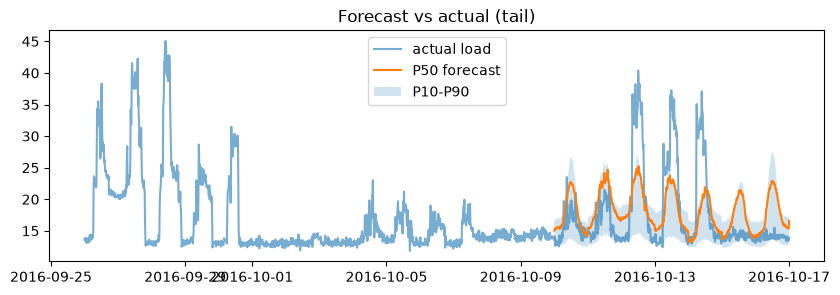

In [16]:
plt.figure(figsize=(10,3))

# actual
plt.plot(load_test.index, 
         load_test["load"], 
         alpha=0.6, 
         label="actual load")

# forecast
plt.plot(forecast_dataset.data.index, forecast_dataset.data["quantile_P50"], label="P50 forecast")

# 'confidence' interval
plt.fill_between(forecast_dataset.data.index, 
                 forecast_dataset.data["quantile_P10"], 
                 forecast_dataset.data["quantile_P90"], 
                 alpha=0.2, 
                 label="P10-P90")

plt.legend()
plt.title("Forecast vs actual (tail)")
plt.show()

# Test Inference

In [17]:
history=load_test[test_start : forecast_start-load_adapter.openstef_adapter.sample_interval]

In [18]:
inference_forecast = load_adapter.forecast_load_kW(history=history, 
                          at=forecast_start,
                          horizon=pd.Timedelta(7, "D"))

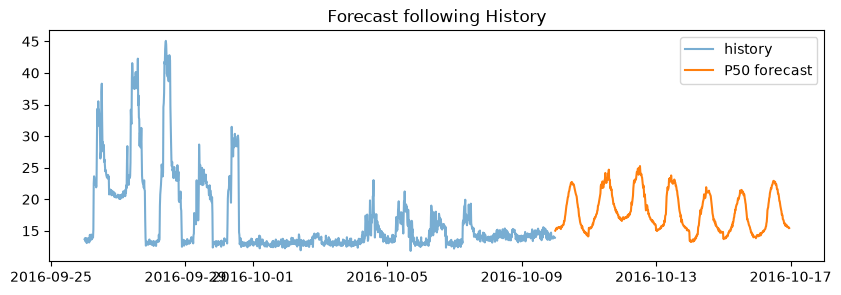

In [19]:
plt.figure(figsize=(10,3))

# history
plt.plot(history.index, 
         history["load"], 
         alpha=0.6, 
         label="history")

# forecast
plt.plot(inference_forecast.index, inference_forecast, label="P50 forecast")

plt.legend()
plt.title("Forecast following History")
plt.show()